In [36]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader , TensorDataset
from torchvision.utils import save_image, make_grid
from torch.optim import Adam
import torch.nn.init as init

import numpy as np
import math

import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import MultipleLocator
import matplotlib.cm as cm
from matplotlib.cm import get_cmap

import copy
import seaborn as sns

from scipy.stats import norm
from sklearn.neighbors import KernelDensity, LocalOutlierFactor
from sklearn.decomposition import PCA

import tqdm
import pickle

# MI estimators
# from utils.estimators import *

In [37]:
def import_data(mode:list , num_policy:int , case:str, level:int=5):
    dataset = {key : [] for key in mode}
    for i in dataset.keys():   # run all mode
        for policy in range(num_policy): # each run have 3 policies
            if case == "slope":
                dataset[i].append(np.load(f"../data/{case}/{case}-{i}-ANGLE{str(int)}-policy_{policy}.npy" , allow_pickle=True).item())
            elif case == "mass":
                dataset[i].append(np.load(f"../data/{case}/{case}{level}-{i}-policy_{policy}.npy" , allow_pickle=True).item())
            else:
                dataset[i].append(np.load(f"../data/{case}/{case}-{i}-policy_{policy}.npy" , allow_pickle=True).item())
    for key, value in dataset.items():
        dataset[key] = np.array(value)
    return dataset

In [38]:
NUM_POLICY = 5

mode=["full","vel_act", "pos_act", "pos_vel_act", "act_FC", "act_IMU_FC", "pos_act_IMU", "pos_act_FC", "vel_act_IMU", "vel_act_FC"]
mode=["full", "pos_act_FC", "pos_vel_act" , "CPG_RBF" , "INT-full"  , "INT-pos_vel_act" , "INT-pos_act_FC"]
mode=["full", "pos_act_FC", "pos_vel_act" , "CPG_RBF"]
mode=["full", "pos_act_FC" , "CPG_RBF" , "INT-full"  , "INT-pos_act_FC"]
mode=["pos_act_FC", "ff-full" , "CPG_RBF2", "INT5-pos_act_FC" , "full"]

flat        =   import_data(mode , NUM_POLICY , case="flat")
mass1000    =   import_data(mode , NUM_POLICY , case="mass" , level=1000)
box         =   import_data(mode , NUM_POLICY , case="box")
# ceilling    =   import_data(mode , NUM_POLICY , case="ceilling")
morph       =   import_data(mode , NUM_POLICY , case="morph")
fix_body    =   import_data(mode , NUM_POLICY , case="fix_body")
loss100     =   import_data(mode , NUM_POLICY , case="loss100")

# [case:str][number_file:int][data/brain:str]

## Plot Trajectories Data

In [39]:
def plot_trajectory(dataset, case:str,keys:str  ,joint_arr:list ,pol_num:int=0 ,env_num:int=0, t=None):
    trajectory_dataset = dataset[case][pol_num]["data"][keys][: , env_num , joint_arr] # [timestep , num_joint]
    num_row = trajectory_dataset.shape[1]
    if t is None:
        timestep = np.arange(trajectory_dataset.shape[0])
    else:
        t0, t1 = int(t[0]), int(t[1])                 # minimal: just use provided window
        timestep = np.arange(t0, t1)
        trajectory_dataset = trajectory_dataset[t0:t1, :]   # <-- NEW: slice data to match x


    fig, axes = plt.subplots(nrows=num_row, ncols=1, figsize=(10, 3*num_row), sharex=True, sharey=False)
    for i, ax in enumerate(axes):
        joint_idx = joint_arr[i]
        ax.plot(timestep, trajectory_dataset[:, i])
        ax.set_ylabel(f"j{joint_idx}")
        ax.grid(True, alpha=0.3)
        ax.set_title(f"{keys} • policy {pol_num}, env {env_num} • joint[{joint_idx}]", fontsize=10)

def plot_compare_trajectory(dataset, case:str, keys:str , dataset2, case2:str, keys2:str,joint_arr:list ,pol_num:int=0 ,env_num:int=0, t=None):
    trajectory_dataset = dataset[case][pol_num]["data"][keys][: , env_num , joint_arr] # [timestep , num_joint]
    trajectory_dataset2 = dataset2[case2][pol_num]["data"][keys2][: , env_num , joint_arr] # [timestep , num_joint]

    num_row = trajectory_dataset.shape[1]
    if t is None:
        timestep = np.arange(trajectory_dataset.shape[0])
    else:
        t0, t1 = int(t[0]), int(t[1])                 # minimal: just use provided window
        timestep = np.arange(t0, t1)
        trajectory_dataset = trajectory_dataset[t0:t1, :]   # <-- NEW: slice data to match x

    fig, axes = plt.subplots(nrows=num_row, ncols=1, figsize=(10, 3*num_row), sharex=True, sharey=False)
    for i, ax in enumerate(axes):
        joint_idx = joint_arr[i]
        ax.plot(timestep, trajectory_dataset[:, i])
        ax.plot(timestep, trajectory_dataset2[:, i])
        ax.set_ylabel(f"j{joint_idx}")
        ax.grid(True, alpha=0.3)
        ax.set_title(f"{keys} • policy {pol_num}, env {env_num} • joint[{joint_idx}]", fontsize=10)

def plot_compare_keys(
    dataset,
    case: str,
    keys: list,              # list of keys to compare, e.g. ["post_rbf", "action", "pre_rbf"]
    joint_arr: list,         # joints you want to plot
    pol_num: int = 0,
    env_num: int = 0,
    t=None,
    labels: list = None      # optional custom labels for legend (same length as keys)
):
    # take the first key to get shape / timesteps
    first_key = keys[0]
    base_traj = dataset[case][pol_num]["data"][first_key][:, env_num, joint_arr]
    num_row = base_traj.shape[1]

    # time axis
    if t is None:
        t0, t1 = 0, base_traj.shape[0]
    else:
        t0, t1 = int(t[0]), int(t[1])

    timestep = np.arange(t0, t1)

    # prepare all trajectories in a dict: key -> [T, num_joints]
    traj_dict = {}
    for k in keys:
        arr = dataset[case][pol_num]["data"][k][:, env_num, joint_arr]
        traj_dict[k] = arr[t0:t1, :]

    # fallback labels
    if labels is None:
        labels = keys
    assert len(labels) == len(keys), "labels must have the same length as keys"

    fig, axes = plt.subplots(
        nrows=num_row,
        ncols=1,
        figsize=(10, 3 * num_row),
        sharex=True,
        sharey=False
    )

    # make axes iterable even if num_row == 1
    if num_row == 1:
        axes = [axes]

    for i, ax in enumerate(axes):
        joint_idx = joint_arr[i]

        # plot each key on this joint subplot
        for k, label in zip(keys, labels):
            ax.plot(timestep, traj_dict[k][:, i], label=label)

        ax.set_ylabel(f"j{joint_idx}")
        ax.grid(True, alpha=0.3)
        ax.set_title(
            f"{case} • policy {pol_num}, env {env_num} • joint[{joint_idx}]",
            fontsize=10
        )
        ax.legend()

    ax.set_xlabel("timestep")
    fig.tight_layout()
    return fig, axes

def plot_compare_cases_keys(
    dataset,
    case_key_list,
    joint_arr,
    pol_num: int = 0,
    env_num: int = 0,
    t=None,
    sharex: bool = True,
    sharey: bool = False,
    figsize_per_joint=(10, 3),
):
    """
    Compare multiple (case, key) trajectories from the SAME dataset.

    Parameters
    ----------
    dataset : dict-like
        Your big dataset object, e.g. dataset[case][pol_num]["data"][key].

    case_key_list : list[dict]
        Each dict describes ONE curve to plot.
        Required:
            - "case": str  (e.g. "train", "val", "ff", "lstm", etc.)
            - "key":  str  (e.g. "post_rbf", "action", "pre_rbf")

        Optional:
            - "label": str        legend label. If not given, auto-generated.
            - "style": dict       matplotlib kwargs (e.g. {"linestyle": "--", "alpha": 0.7})
            - "pol_num": int      overrides global pol_num for this curve
            - "env_num": int      overrides global env_num for this curve

        Example:
        case_key_list = [
            {"case": "ff",   "key": "action", "label": "FF • action"},
            {"case": "lstm", "key": "action", "label": "LSTM • action",
             "style": {"linestyle": "--"}},
            {"case": "hebb", "key": "post_rbf", "label": "Hebb • post_rbf"},
        ]

    joint_arr : list[int]
        Joint indices to plot (e.g. [0, 1, 2]).

    pol_num, env_num : int
        Default policy/env index (can be overridden per curve in case_key_list).

    t : tuple(int, int) or None
        Time window [t0, t1). If None, uses [0, T_min) across all curves.

    sharex, sharey : bool
        Passed to plt.subplots.

    figsize_per_joint : (float, float)
        Base figure size per joint. Final size = (w, h * num_joints).

    Returns
    -------
    fig, axes
    """

    if len(case_key_list) == 0:
        raise ValueError("case_key_list must not be empty.")

    # --- Collect trajectories ---
    traj_list = []  # each: (label, style, traj[T, num_joints])

    for spec in case_key_list:
        case = spec["case"]
        key  = spec["key"]

        pol  = spec.get("pol_num", pol_num)
        env  = spec.get("env_num", env_num)

        raw = dataset[case][pol]["data"][key]  # [T, num_env, num_joints_total]
        arr = raw[:, env, joint_arr]          # [T, len(joint_arr)]

        label = spec.get("label", f"{case} • {key} • p{pol} • env{env}")
        style = spec.get("style", {})

        traj_list.append((label, style, arr))

    # --- Sync time lengths across curves ---
    lengths = [traj.shape[0] for (_, _, traj) in traj_list]

    if t is None:
        T_min = min(lengths)
        t0, t1 = 0, T_min
    else:
        t0, t1 = int(t[0]), int(t[1])
        t1 = min(t1, min(lengths))
        if t0 < 0 or t0 >= t1:
            raise ValueError(f"Invalid time window t={t} after clamping to lengths {lengths}")

    # Slice by time
    for i, (label, style, traj) in enumerate(traj_list):
        traj_list[i] = (label, style, traj[t0:t1, :])

    timestep = np.arange(t0, t1)
    num_joints = len(joint_arr)

    # --- Create subplots per joint ---
    fig_w, fig_h_per = figsize_per_joint
    fig, axes = plt.subplots(
        nrows=num_joints,
        ncols=1,
        figsize=(fig_w, fig_h_per * num_joints),
        sharex=sharex,
        sharey=sharey,
    )

    if num_joints == 1:
        axes = [axes]

    # --- Plot ---
    for j_idx, ax in enumerate(axes):
        joint_idx = joint_arr[j_idx]

        for label, style, traj in traj_list:
            ax.plot(timestep, traj[:, j_idx], label=label, **style)

        ax.set_ylabel(f"j{joint_idx}")
        ax.grid(True, alpha=0.3)
        ax.set_title(f"joint[{joint_idx}]", fontsize=10)
        ax.legend(fontsize=8)

    axes[-1].set_xlabel("timestep")
    fig.tight_layout()

    return fig, axes

import numpy as np
import matplotlib.pyplot as plt

def plot_compare_dataset_case_keys(
    case_key_list,
    joint_arr,
    default_pol_num: int = 0,
    default_env_num: int = 0,
    t=None,
    sharex: bool = True,
    sharey: bool = False,
    figsize_per_joint=(10, 3),
):
    """
    Compare multiple (dataset, case, key) trajectories.

    Parameters
    ----------
    case_key_list : list[dict]
        Each dict describes ONE curve to plot.

        Required per item:
            - "dataset": dataset object
            - "case":    str, e.g. "full", "train", "val"
            - "key":     str, e.g. "state", "action", "post_rbf"

        Optional per item:
            - "label":   str, legend label
            - "style":   dict, matplotlib kwargs, e.g. {"linestyle": "--", "alpha": 0.7}
            - "pol_num": int, overrides default_pol_num
            - "env_num": int, overrides default_env_num

        Example:
        case_key_list = [
            {"dataset": a, "case": "full", "key": "state", "label": "full"},
            {"dataset": b, "case": "full", "key": "state",
             "label": "full (b)", "style": {"linestyle": "--"}},
        ]

    joint_arr : list[int]
        Joint indices to plot (e.g. [0, 1, 2]).

    default_pol_num, default_env_num : int
        Default policy/env indices if not specified in each item.

    t : tuple(int, int) or None
        Time window [t0, t1). If None, uses [0, T_min) across all curves.

    sharex, sharey : bool
        Passed to plt.subplots.

    figsize_per_joint : (float, float)
        Base figure size per joint. Final size = (w, h * num_joints).

    Returns
    -------
    fig, axes
    """

    if len(case_key_list) == 0:
        raise ValueError("case_key_list must not be empty.")

    # --- Collect trajectories ---
    traj_list = []  # each: (label, style, traj[T, num_joints])

    for spec in case_key_list:
        ds   = spec["dataset"]
        case = spec["case"]
        key  = spec["key"]

        pol  = spec.get("pol_num", default_pol_num)
        env  = spec.get("env_num", default_env_num)

        # raw shape: [T, num_env, num_joints_total]
        raw = ds[case][pol]["data"][key]
        arr = raw[:, env, joint_arr]  # [T, len(joint_arr)]

        label = spec.get("label", f"{case} • {key} • p{pol} • env{env}")
        style = spec.get("style", {})

        traj_list.append((label, style, arr))

    # --- Sync time lengths across curves ---
    lengths = [traj.shape[0] for (_, _, traj) in traj_list]

    if t is None:
        T_min = min(lengths)
        t0, t1 = 0, T_min
    else:
        t0, t1 = int(t[0]), int(t[1])
        t1 = min(t1, min(lengths))
        if t0 < 0 or t0 >= t1:
            raise ValueError(f"Invalid time window t={t} after clamping to lengths {lengths}")

    # Slice by time
    for i, (label, style, traj) in enumerate(traj_list):
        traj_list[i] = (label, style, traj[t0:t1, :])

    timestep = np.arange(t0, t1)
    num_joints = len(joint_arr)

    # --- Create subplots per joint ---
    fig_w, fig_h_per = figsize_per_joint
    fig, axes = plt.subplots(
        nrows=num_joints,
        ncols=1,
        figsize=(fig_w, fig_h_per * num_joints),
        sharex=sharex,
        sharey=sharey,
    )

    if num_joints == 1:
        axes = [axes]

    # --- Plot ---
    for j_idx, ax in enumerate(axes):
        joint_idx = joint_arr[j_idx]

        for label, style, traj in traj_list:
            ax.plot(timestep, traj[:, j_idx], label=label, **style)

        ax.set_ylabel(f"j{joint_idx}")
        ax.grid(True, alpha=0.3)
        ax.set_title(f"joint[{joint_idx}]", fontsize=10)
        ax.legend(fontsize=8)

    axes[-1].set_xlabel("timestep")
    fig.tight_layout()

    return fig, axes

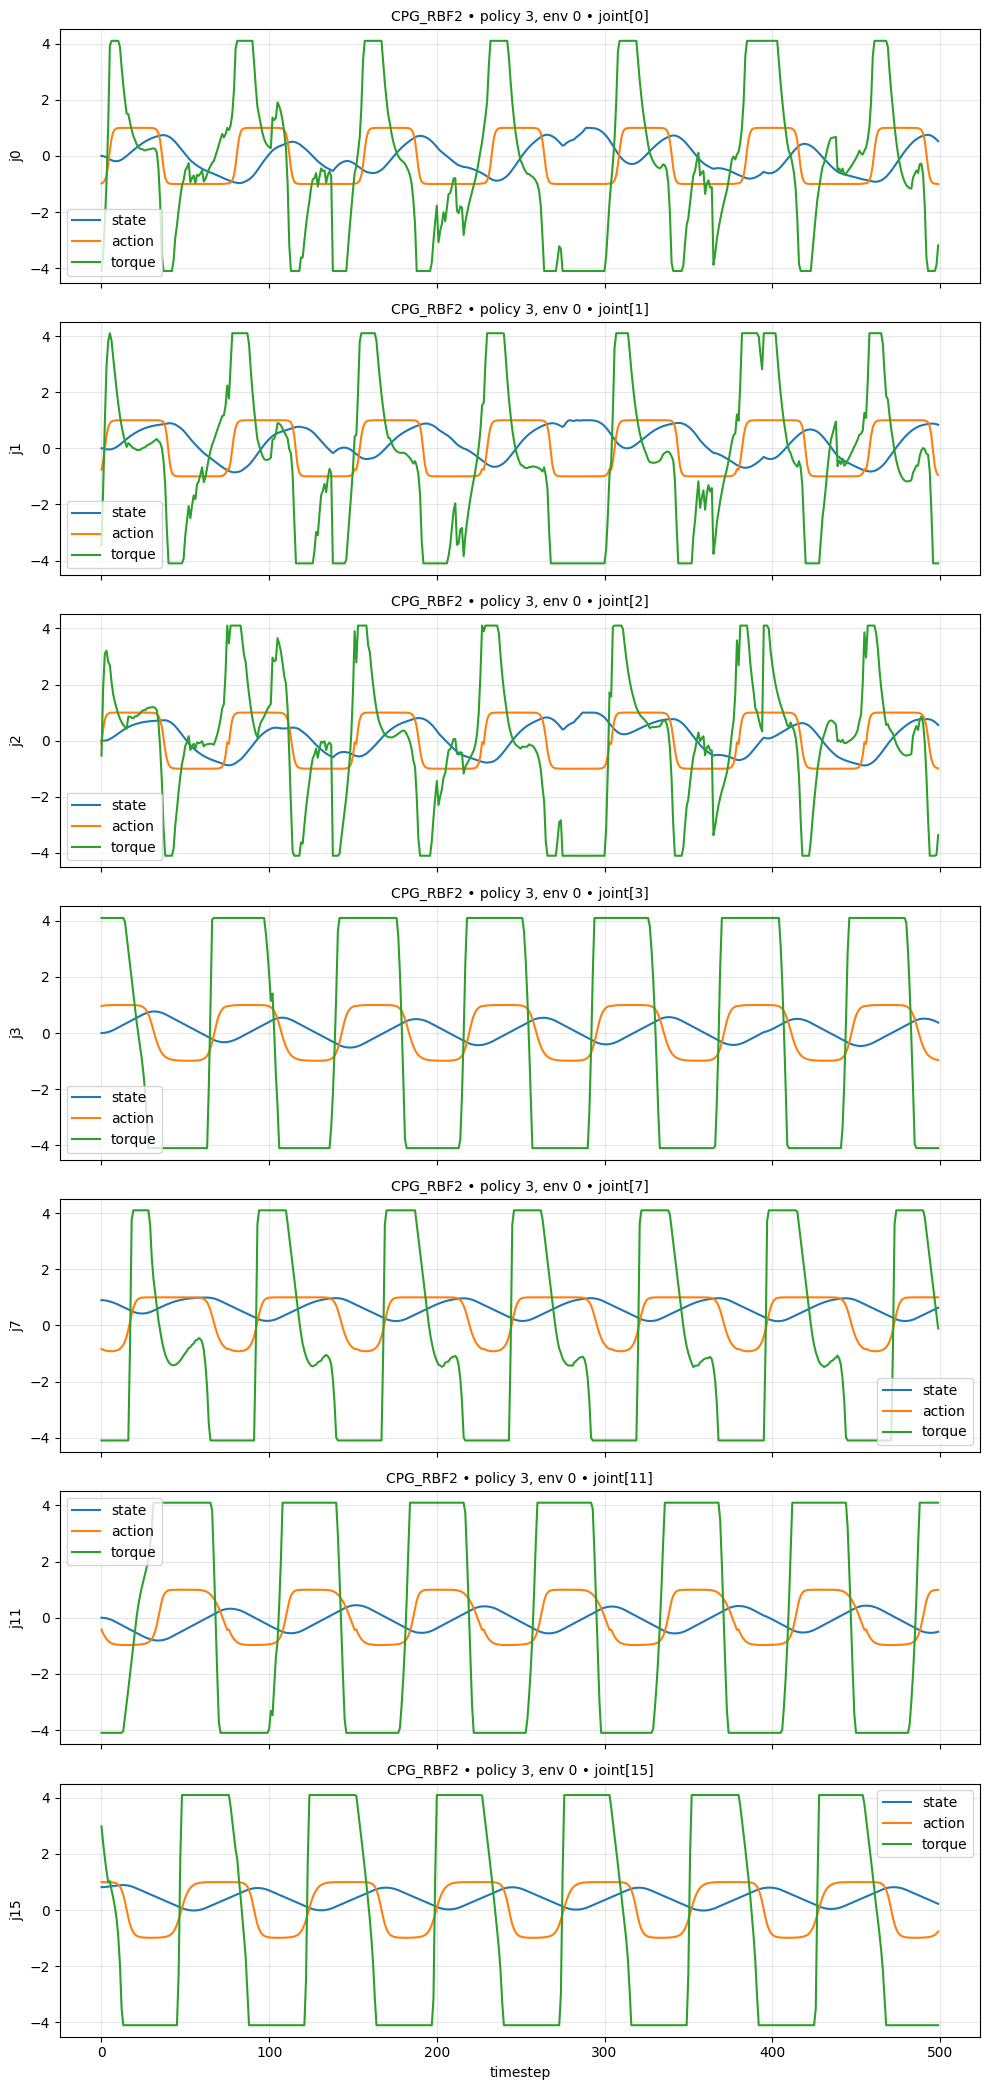

In [40]:
joint_arr = [0,1,2,3,7,11,15]
# joint_arr = [3+1,7+1,11+1,15+1]
# joint_arr = [3+2,7+2,11+2,15+2]
# joint_arr = [3+3,7+3,11+3,15+3]
# joint_arr = [0,3,4]

# plot_trajectory(dataset=dataset,case="INT-full", pol_num=0,keys="post_rbf" , joint_arr=[0,1,2,3,4,5,6] , t=[0,500])

_ = plot_compare_keys(
    dataset=box,
    case="CPG_RBF2",
    keys=[ "state" , "action" , "torque"],
    joint_arr=joint_arr,
    pol_num=3,
    env_num=0,
    t=[0, 500],
    labels=[ "state" , "action", "torque"]
)

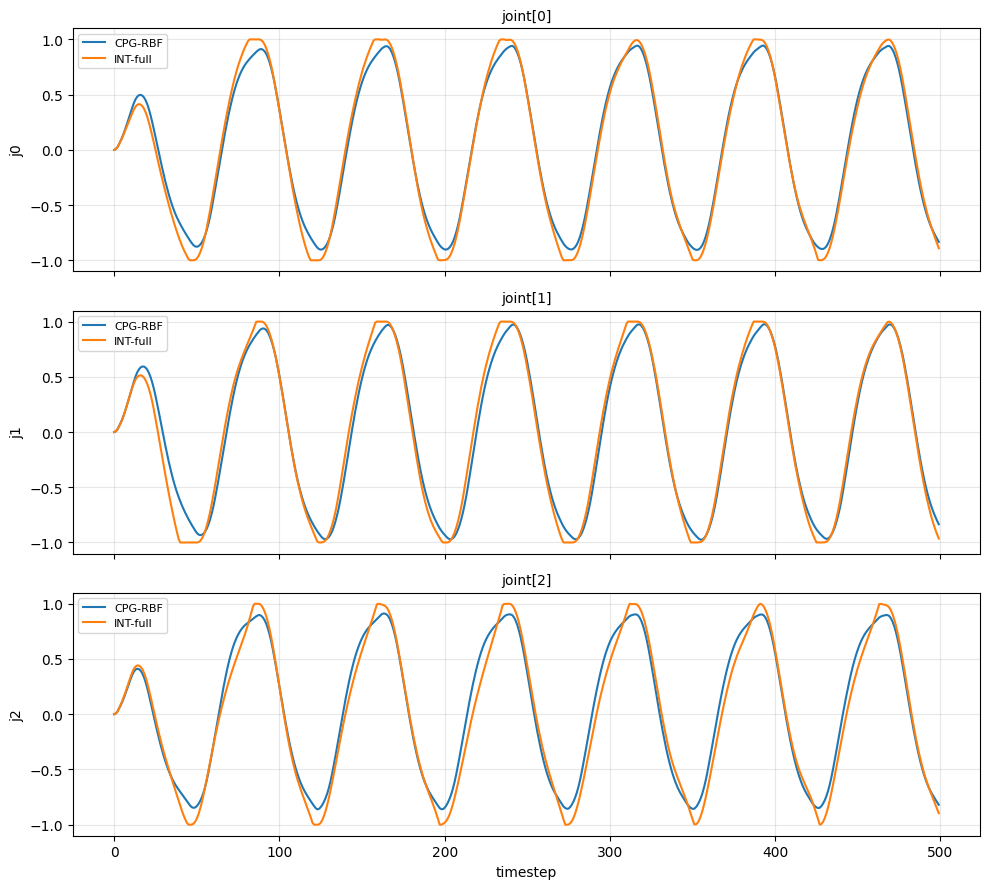

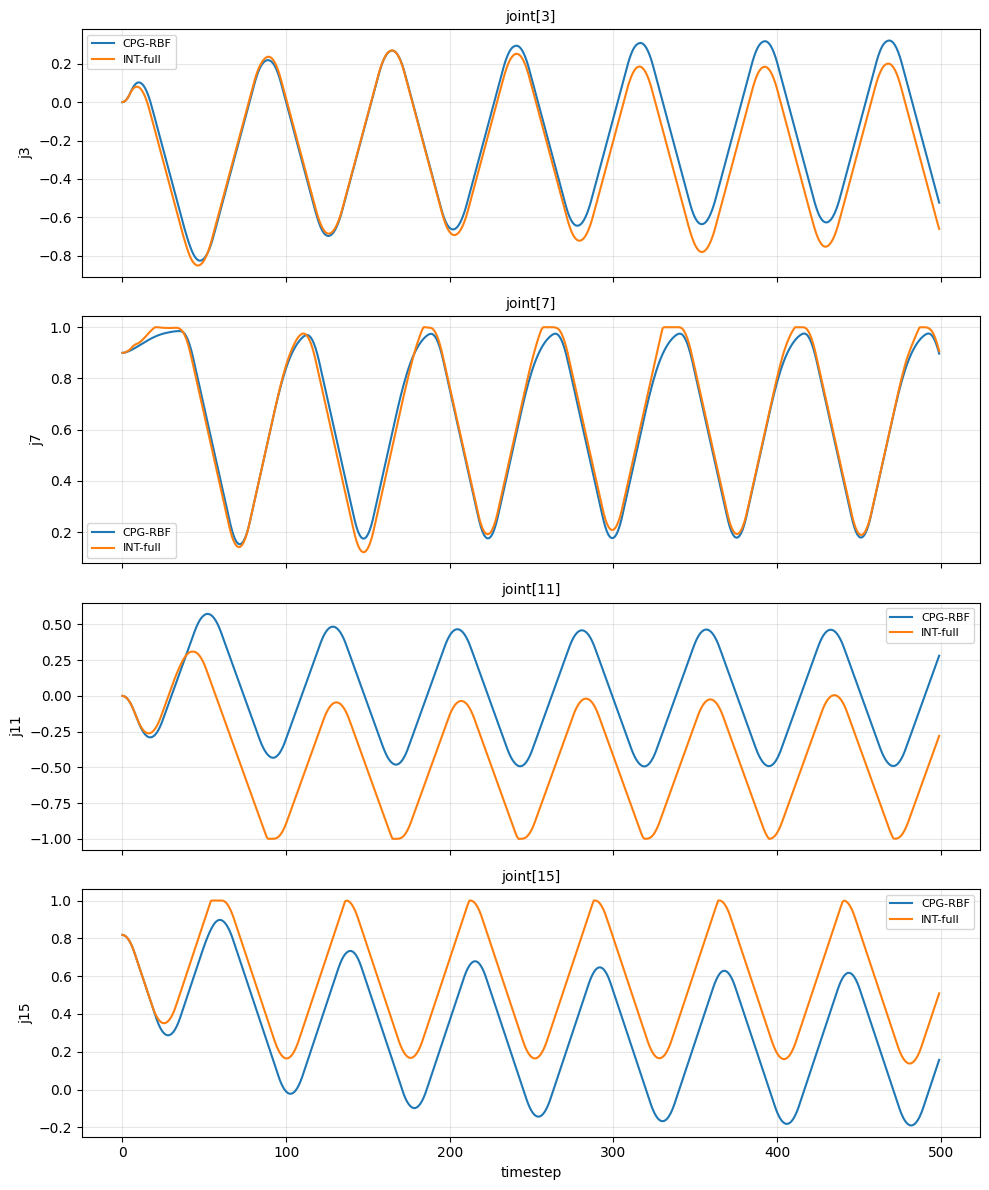

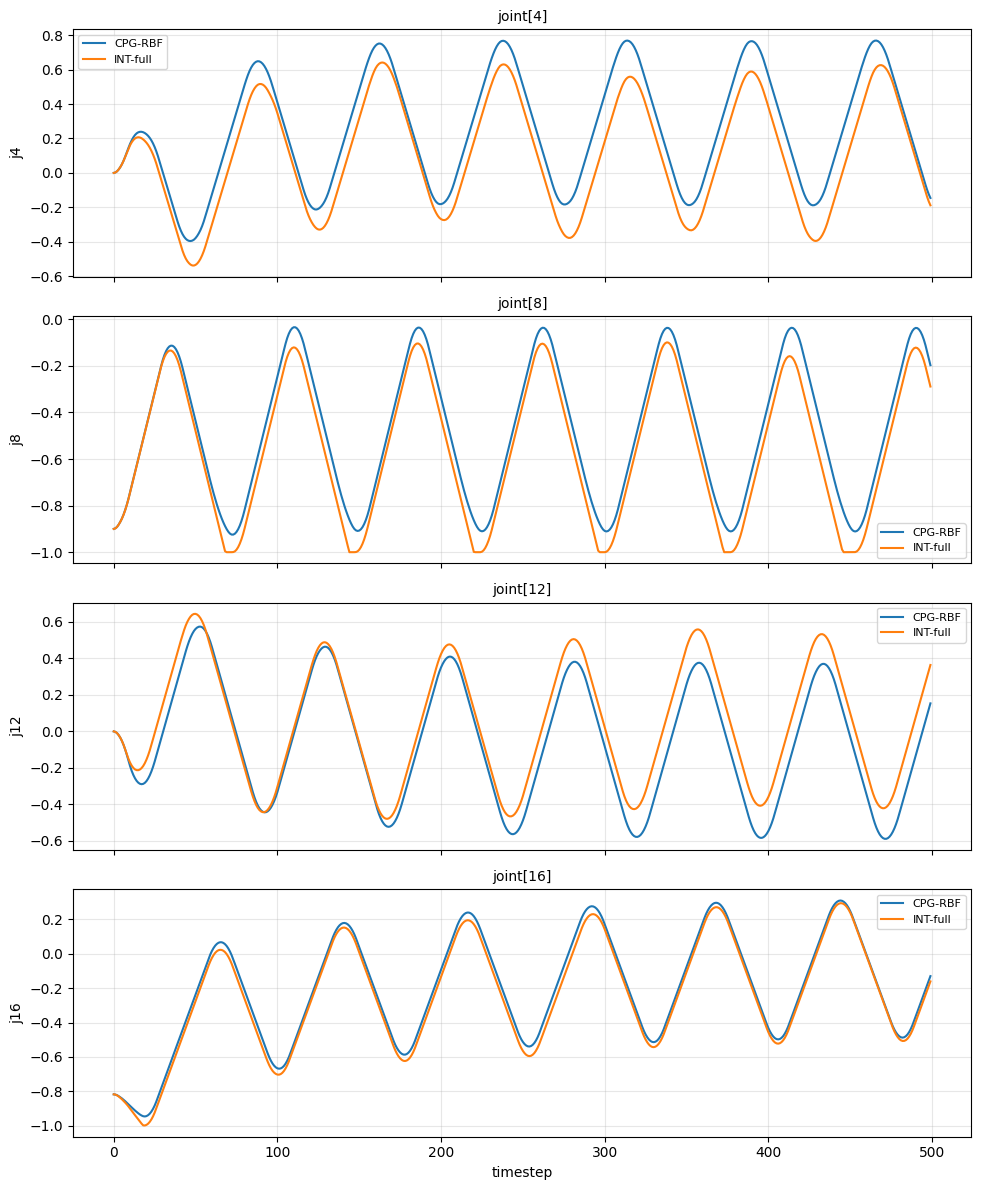

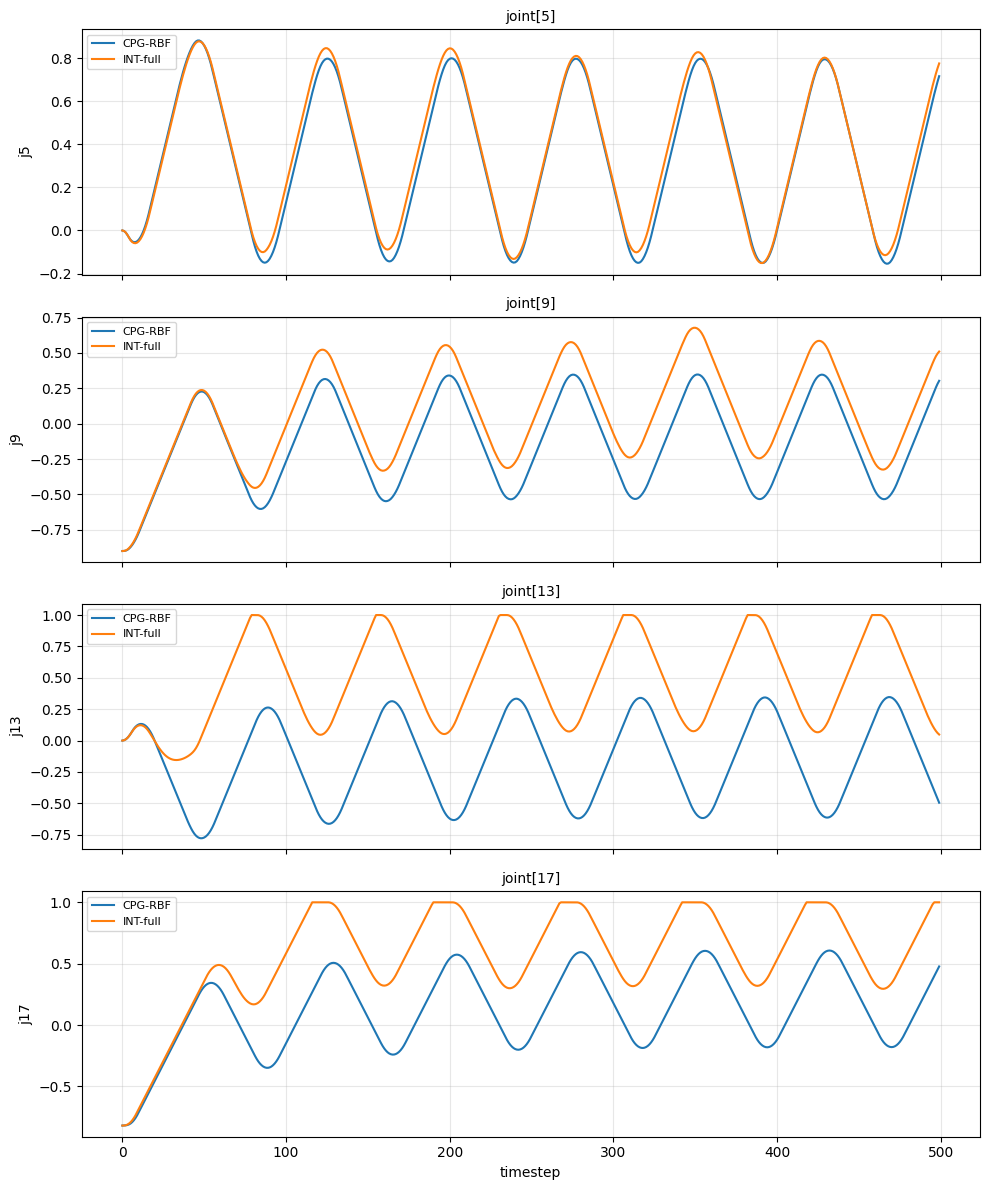

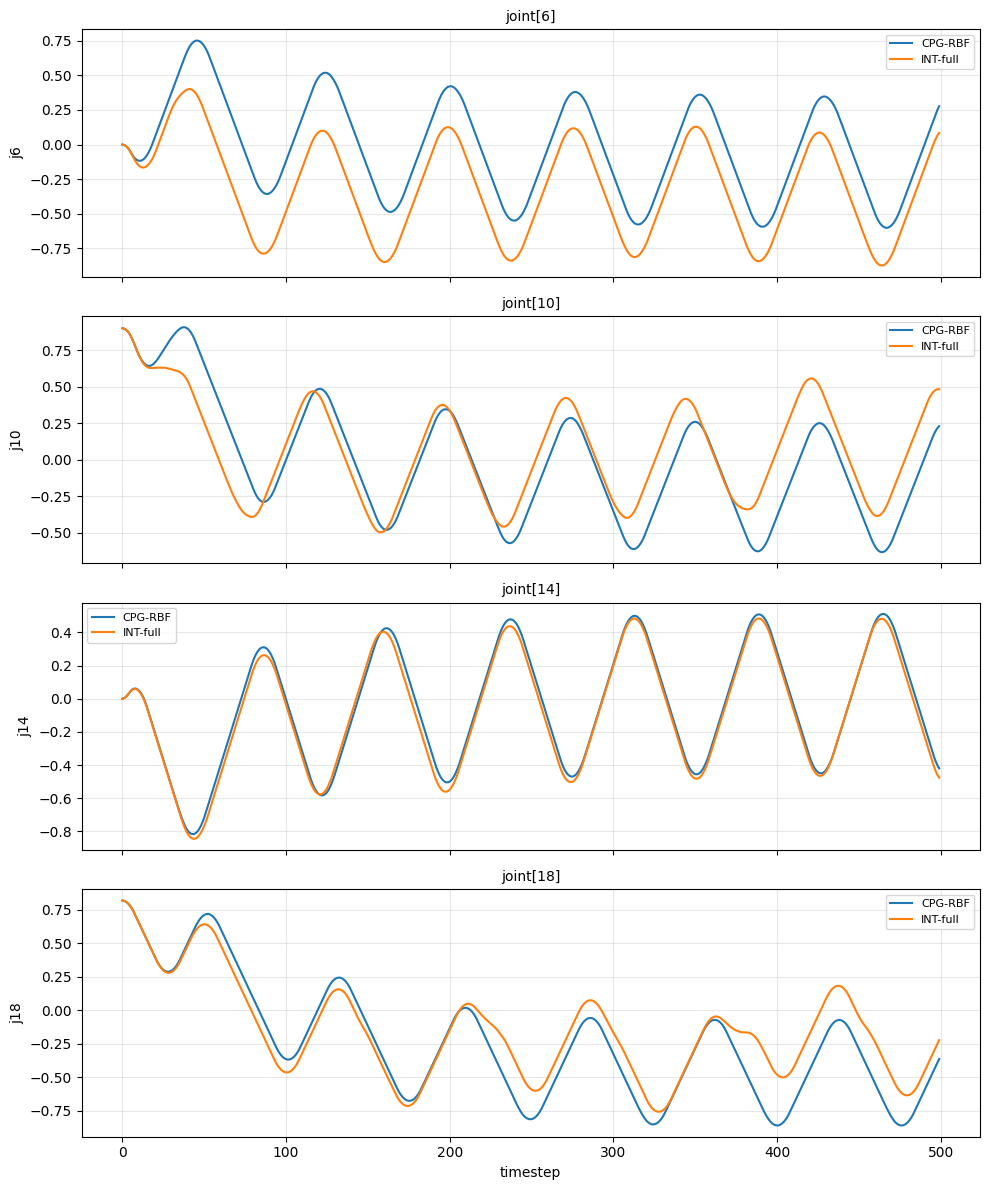

In [41]:
case_key_list = [
    {"case": "CPG_RBF2",   "key": "state",   "label": "CPG-RBF"},
    # {"case": "INT-pos_act_fc", "key": "state",   "label": "full", "style": {"linestyle": "--"}},
    {"case": "INT5-pos_act_FC", "key": "state", "label": "INT-full",}, #"style": {"linestyle": ":"}},

    # {"case": "pos_act_FC", "key": "state", "label": "pos_act_FC",} #"style": {"linestyle": ":"}},
]

policy_num = 0
env_num = 0
data = flat
fig, axes = plot_compare_cases_keys(
    dataset=data,
    case_key_list=case_key_list,
    joint_arr=[0,1,2],
    pol_num=policy_num,
    env_num=env_num,
    t=(0, 1000),   # or None for full
)

fig, axes = plot_compare_cases_keys(
    dataset=data,
    case_key_list=case_key_list,
    joint_arr=[3,7,11,15],
    pol_num=policy_num,
    env_num=env_num,
    t=(0, 1000),   # or None for full
)

fig, axes = plot_compare_cases_keys(
    dataset=data,
    case_key_list=case_key_list,
    joint_arr=[4,8,12,16],
    pol_num=policy_num,
    env_num=env_num,
    t=(0, 1000),   # or None for full
)

fig, axes = plot_compare_cases_keys(
    dataset=data,
    case_key_list=case_key_list,
    joint_arr=[5,9,13,17],
    pol_num=policy_num,
    env_num=env_num,
    t=(0, 1000),   # or None for full
)

fig, axes = plot_compare_cases_keys(
    dataset=data,
    case_key_list=case_key_list,
    joint_arr=[6,10,14,18],
    pol_num=policy_num,
    env_num=env_num,
    t=(0, 1000),   # or None for full
)
plt.show()

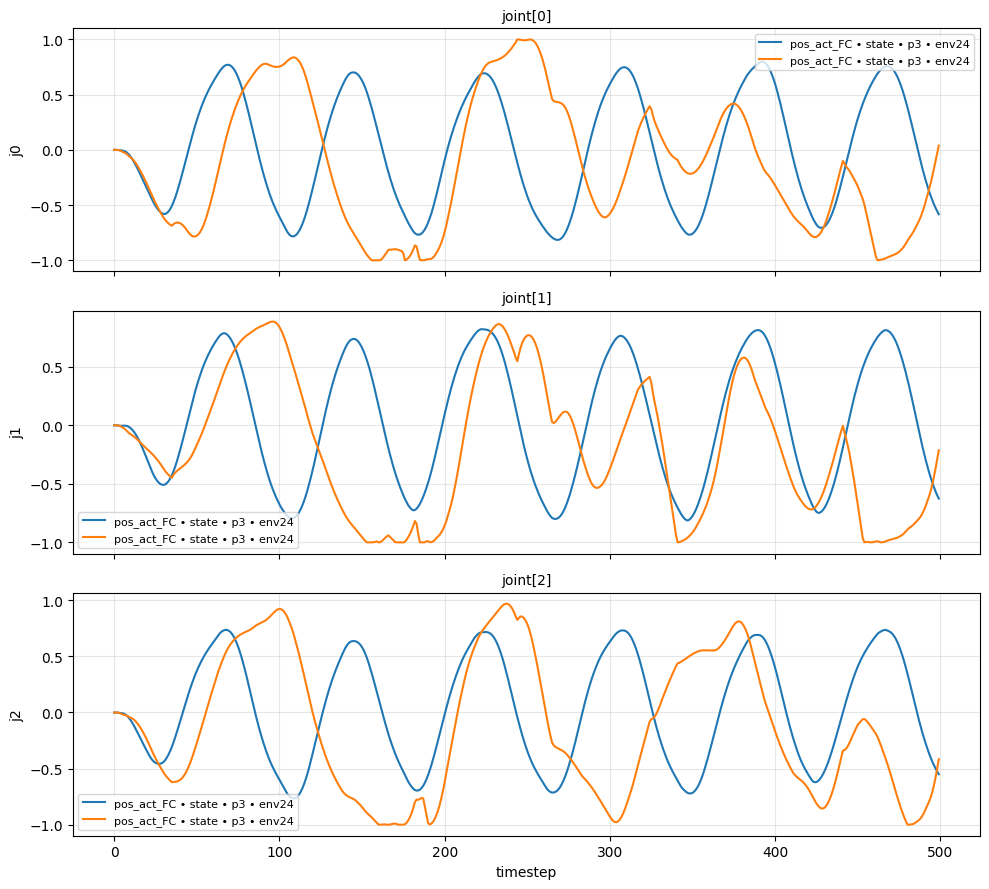

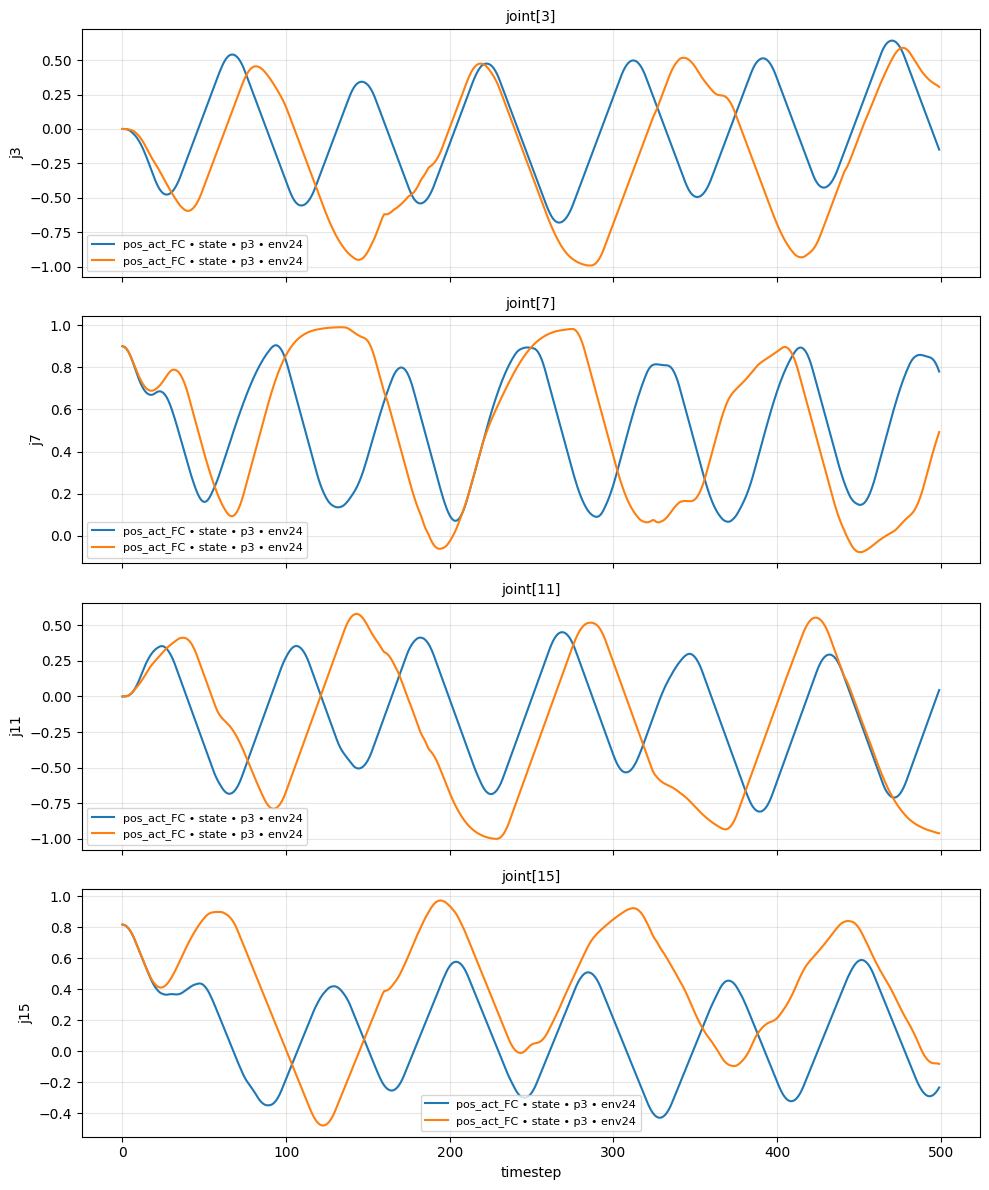

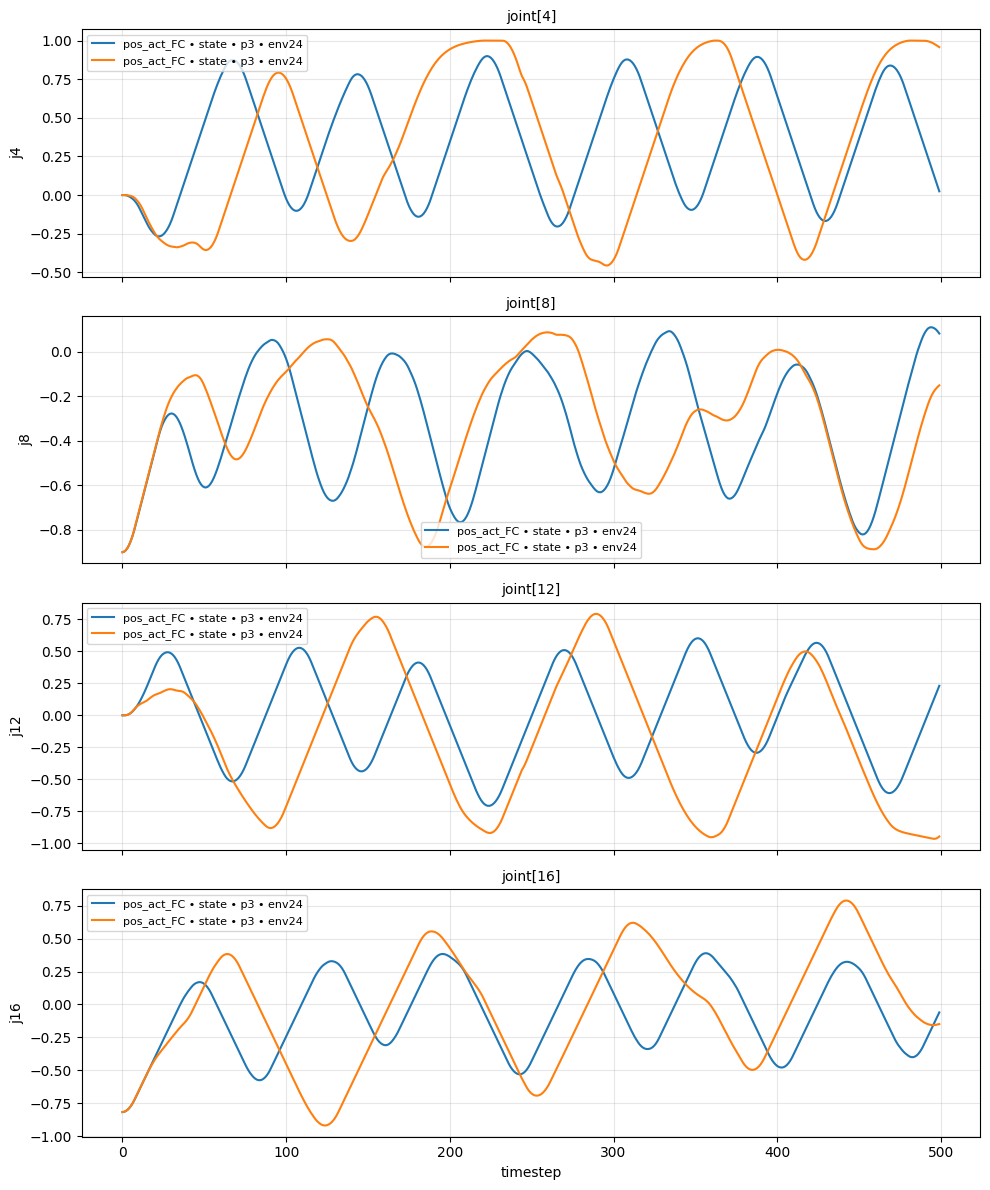

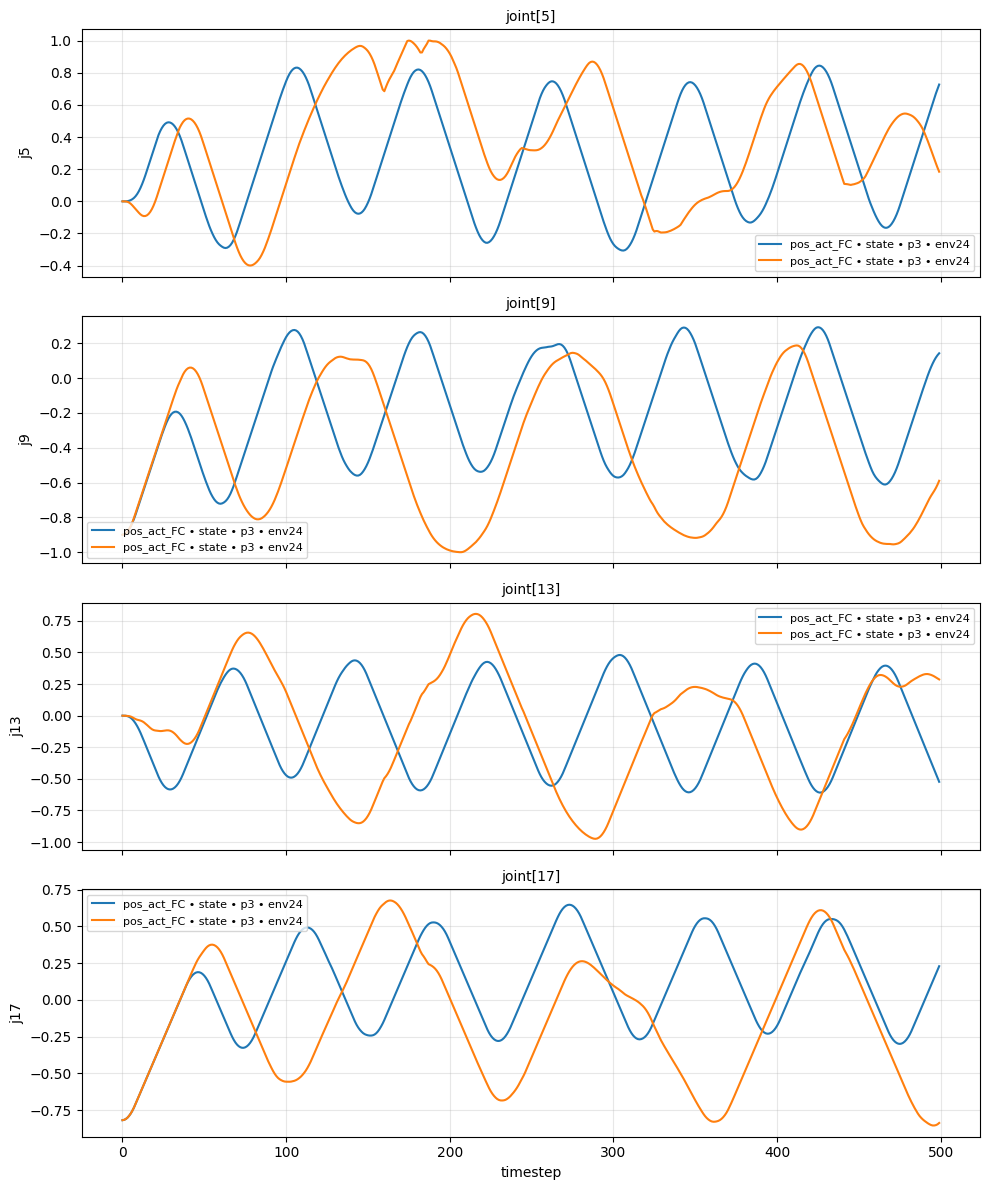

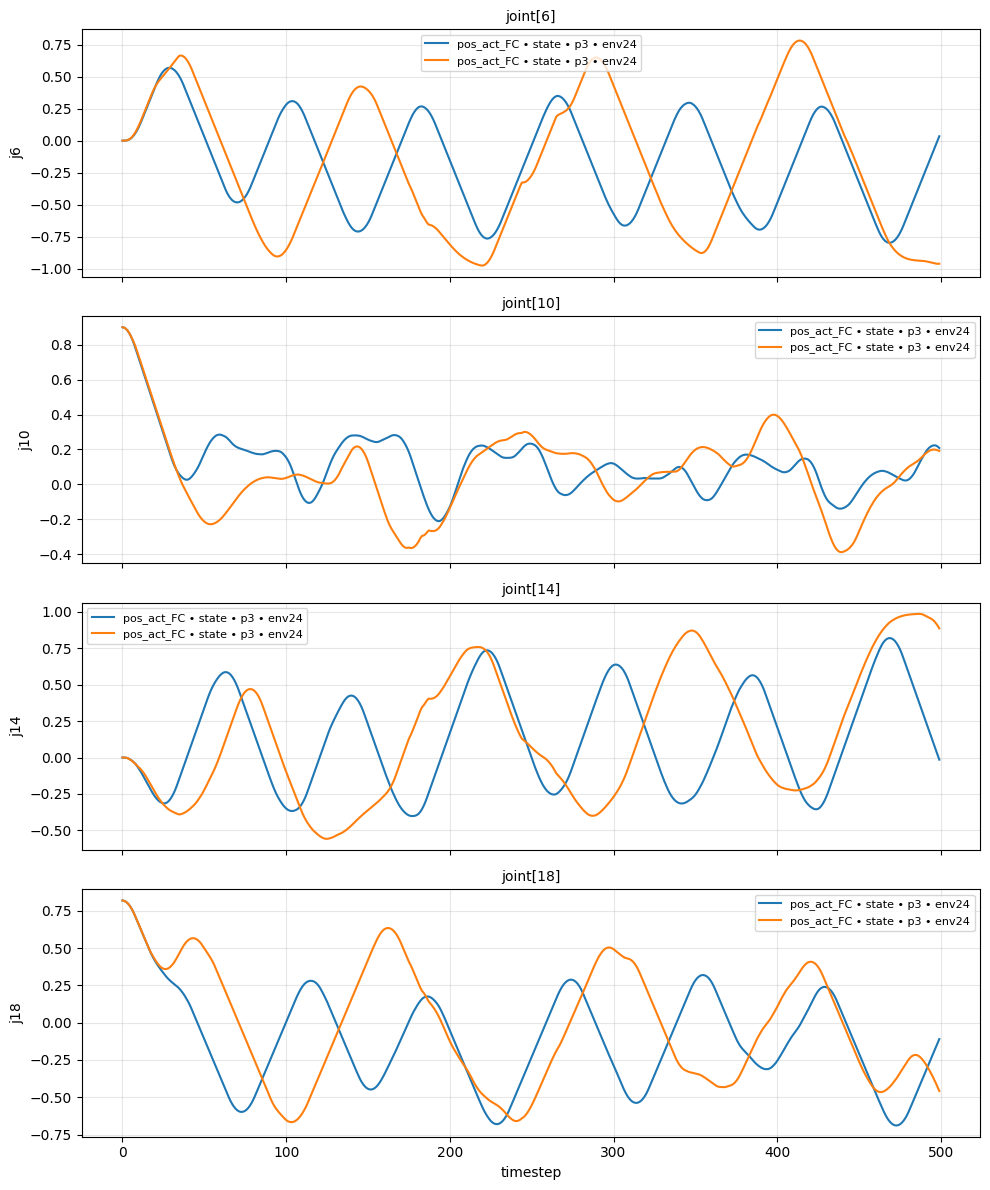

In [61]:
# INT5-pos_act_FC CPG_RBF2
case_key_list = [
    # {"dataset": flat, "case": "INT5-pos_act_FC", "key": "state",  "label": "state"},
    # {"dataset": loss100, "case": "INT5-pos_act_FC", "key": "dof_pos",},
    # {"dataset": loss100, "case": "INT5-pos_act_FC", "key": "post_rbf",},
    # {"dataset": loss100, "case": "INT5-pos_act_FC", "key": "hebb_action",},
    {"dataset": flat, "case": "pos_act_FC", "key": "state",},
    {"dataset": box, "case": "pos_act_FC", "key": "state",},
    # {"dataset": morph, "case": "pos_act_FC", "key": "action", },
    # {"dataset": morph, "case": "ff-full", "key": "action", },
    # {"dataset": flat, "case": "CPG_RBF2", "key": "torque", "label": "torque"},
]

policy_num=3
env_num=24

fig, axes = plot_compare_dataset_case_keys(
    case_key_list=case_key_list,
    joint_arr=[0,1,2],
    default_pol_num=policy_num,
    default_env_num=env_num,
    t=(0, 500),
)
fig, axes = plot_compare_dataset_case_keys(
    case_key_list=case_key_list,
    joint_arr=[3,7,11,15],
    default_pol_num=policy_num,
    default_env_num=env_num,
    t=(0, 500),
)
fig, axes = plot_compare_dataset_case_keys(
    case_key_list=case_key_list,
    joint_arr=[4,8,12,16],
    default_pol_num=policy_num,
    default_env_num=env_num,
    t=(0, 500),
)
fig, axes = plot_compare_dataset_case_keys(
    case_key_list=case_key_list,
    joint_arr=[5,9,13,17],
    default_pol_num=policy_num,
    default_env_num=env_num,
    t=(0, 500),
)
fig, axes = plot_compare_dataset_case_keys(
    case_key_list=case_key_list,
    joint_arr=[6,10,14,18],
    default_pol_num=policy_num,
    default_env_num=env_num,
    t=(0, 500),
)
plt.show()

'joint0_m', 'joint0_h', 'joint0_f' = [
    [-0.2618, -0.2618, -0.2618],
    [0.2618, 0.2618, 0.2618]
]

'joint1_rf', 'joint1_lf', 'joint1_rh', 'joint1_lh' = [
    [-0.7854, -0.7854, -0.7854, -0.7854],
    [0.7854, 0.7854, 0.7854, 0.7854]
]

'joint2_rf', 'joint2_lf', 'joint2_rh', 'joint2_lh' = [
    [-1.6581,-0.0873, -0.0873, -1.6581] ,
    [0.0873, 1.6581, 1.6581, 0.0873]
]

'joint3_rf', 'joint3_lf', 'joint3_rh', 'joint3_lh' = [
    [-0.7854, -0.7854, -0.7854, -0.7854] ,
    [0.7854, 0.7854, 0.7854, 0.7854]
]

'joint4_rf', 'joint4_lf', 'joint4_rh', 'joint4_lh' = [
    [-1.7453,-0.1745, -0.1745, -1.7453],
    [0.1745, 1.7453, 1.7453,0.1745]
     ]



    

## FC diagram
